<a href="https://colab.research.google.com/github/sreesweetha/datacleaning-and-EDA/blob/main/Datacleaning_and_EDA_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Working in the dataset of Titanic dataset for datacleaning and EDA
**#Import the libaries**

In [15]:
import pandas as pd
import numpy as np


**loading the csv dataset**

In [16]:
df=pd.read_csv("/content/tested.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [17]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df["Age"]=df["Age"].fillna(df["Age"].median())

Embarked is one of the features (columns) in the Titanic dataset that indicates the port where a passenger boarded the ship.In this dataset, the values are usually abbreviated using three letters:

S: Southampton (England)

C: Cherbourg (France)

Q: Queenstown (now Cobh, Ireland)

In [20]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [21]:
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 39.3+ KB


In [23]:
df.drop(columns=['Cabin'], inplace=True)

In [24]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,2
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,0
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,2
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,0
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,0
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,27.0,0,0,A.5. 3236,8.0500,0
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,1
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,0
416,1308,0,3,"Ware, Mr. Frederick",male,27.0,0,0,359309,8.0500,0


In [27]:
df["Fare"]=df["Fare"].fillna(df["Fare"].median())

In [28]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**Visualizing Key Features**

Univariate

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns


##Distribution of the Target Variable (Survived) by countplot

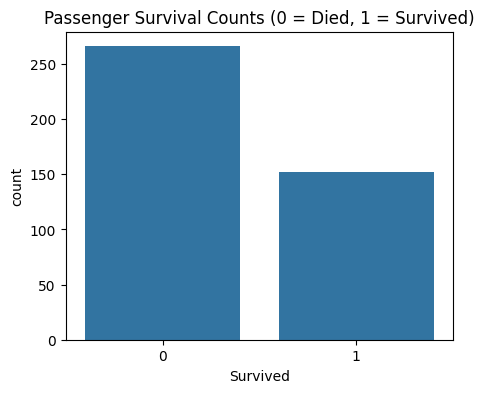

In [30]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Survived')
plt.title('Passenger Survival Counts (0 = Died, 1 = Survived)')
plt.show()

**Bivariate** ----relationship between two variables.

##Age Distribution of Survivors vs Non-Survivors by histogram

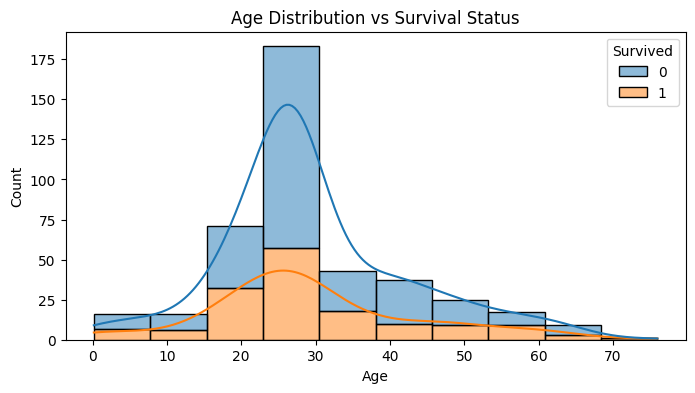

In [33]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, multiple='stack', bins=10)
plt.title('Age Distribution vs Survival Status')
plt.show()

# ##Distrubution of Age and Fare with Scatter plot

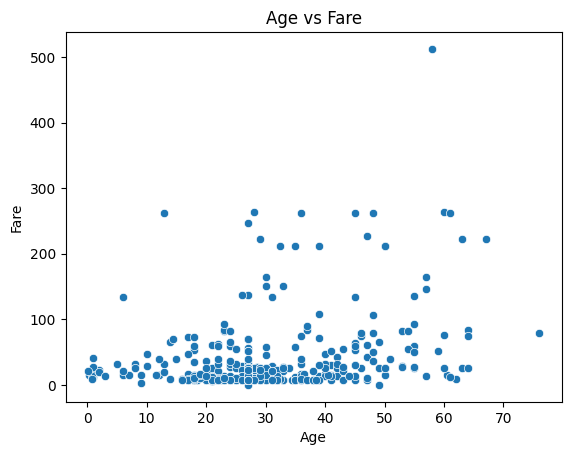

In [35]:
sns.scatterplot(data=df, x="Age", y="Fare")
plt.title("Age vs Fare")
plt.show()

**Multivariate** relationship between 3 or more variables.

##Correlation Heatmap

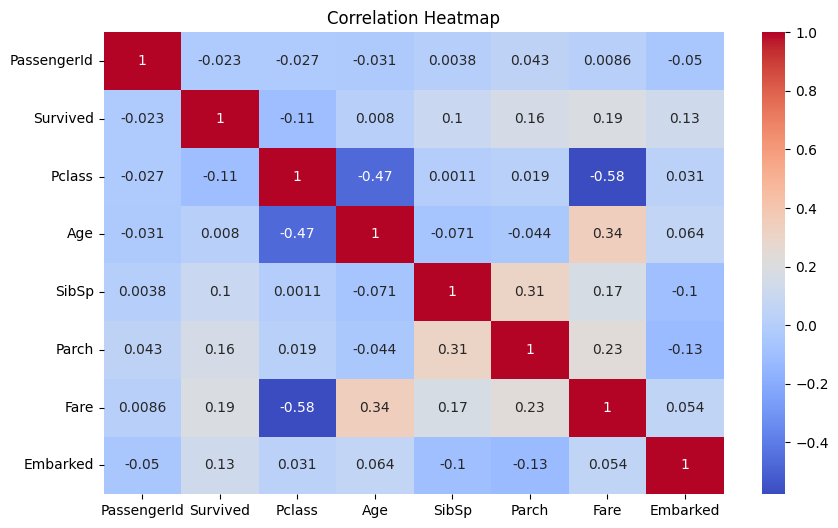

In [37]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()